### Permutation Tests in Squidpy 
- Cell-type co-localisation - are cell types enriched together more than expected by chance?  
**Null hypothesis**: spatial features (e.g cell-type arrangement) are random.    
- We test this by rnadomly shuffling cell locations, gene expression values or samples many times and comparing the observed statistic to this random distribution. 

In [8]:

import squidpy as sq
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import warnings

warnings.filterwarnings("ignore")

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [5]:
adata = sq.datasets.merfish()

# the dataset contains multiple slides, we only use one for now
adata = adata[adata.obs.Bregma == -9]

# we'll use this later for plotting
sc.pp.neighbors(adata)
sc.tl.umap(adata)

adata
# the `Cell_class` column is the cell type annotation

  0%|          | 0.00/49.2M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 6185 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors', 'pca', 'neighbors', 'umap'
    obsm: 'spatial', 'spatial3d', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [6]:
adata.obs

,Cell_ID,Animal_ID,Animal_sex,Behavior,Bregma,Centroid_X,Centroid_Y,Cell_class,Neuron_cluster_ID,batch
41437-4,8c7df84c-8a53-4aa4-86fd-26e575de9b0e,1,Female,Naive,-9.0,1313.511887,2162.459959,Microglia,nan,4
41438-4,3617ee7c-c0a8-4f18-b9bd-c7ca737ff665,1,Female,Naive,-9.0,1321.787911,2288.708578,Astrocyte,nan,4
41439-4,f0d0277a-cac1-4181-8528-abfd9a5403c0,1,Female,Naive,-9.0,1333.694106,2116.464893,Astrocyte,nan,4
41440-4,2dbbce4f-c54f-4df8-aced-590c971db48a,1,Female,Naive,-9.0,1339.956433,2200.067589,Astrocyte,nan,4
41441-4,74d3f69d-e8f2-4c33-a8ca-fac3eb65e55a,1,Female,Naive,-9.0,1340.563484,2251.463695,Endothelial 1,nan,4
...,...,...,...,...,...,...,...,...,...,...
47617-4,7a0e3ee6-aa12-4ed8-80ae-465e186caa3f,1,Female,Naive,-9.0,3060.524623,3700.928535,Inhibitory,I-9,4
47618-4,6a2e534c-e94e-45d0-ae8b-a0459133d53b,1,Female,Naive,-9.0,3096.962169,3534.935314,Inhibitory,I-18,4
47619-4,0e5b91a1-43f1-4821-8d36-ec587850de66,1,Female,Naive,-9.0,2907.293885,3524.461287,Ambiguous,nan,4
47620-4,cc5fb740-cdd3-4456-999e-ad433c68d350,1,Female,Naive,-9.0,2908.555041,3568.968505,Ambiguous,nan,4


In [9]:
import squidpy as sq

# Ensure spatial coordinates are in the correct format
adata.obsm["spatial"] = adata.obs[["Centroid_X", "Centroid_Y"]].values

# Compute spatial neighbors (required for co-occurrence analysis)
sq.gr.spatial_neighbors(adata, coord_type="generic")  # Use "grid" if working with spatial transcriptomics data


### Cell type co-occurrence tests 
- are certain cell-types clustering together more than expected by chance?
- **Why it matters**: helps identify functionally important cell neighbourhood (*e.g if immune cells cluster near cancer cells more than expected by chance, it suggests immune infiltration)

1. Computes the real cell-type co-occurrence matrix.
2. Randomly shuffles cell-type labels across spatial locations.
3. Compares observed vs shuffled co-occurrence to compute a p-value.

In [15]:
import squidpy as sq
import numpy as np

# Compute co-occurrence for the actual cell types
sq.gr.co_occurrence(adata, cluster_key="Cell_class")
print(adata.uns.keys())  # Ensure 'Cell_class_co_occurrence' exists

# Extract the observed interaction matrix
observed_matrix = adata.uns["Cell_class_co_occurrence"]["occ"].copy()

# Define number of permutations
n_permutations = 5
random_matrices = []

for _ in range(n_permutations):
    # Shuffle cell-type labels
    shuffled_classes = np.random.permutation(adata.obs["Cell_class"])

    # Store shuffled data as categorical
    adata.obs["shuffled_Cell_class"] = pd.Categorical(shuffled_classes, categories=adata.obs["Cell_class"].unique())

    # Compute co-occurrence on shuffled data
    sq.gr.co_occurrence(adata, cluster_key="shuffled_Cell_class")

    # Store the permuted interaction matrix
    permuted_matrix = adata.uns["shuffled_Cell_class_co_occurrence"]["occ"].copy()
    random_matrices.append(permuted_matrix)

# Convert to NumPy array
random_matrices = np.array(random_matrices)

# Compute p-values (how often does the permuted result exceed the observed?)
p_values = (random_matrices >= observed_matrix).sum(axis=0) / n_permutations

# Store results in AnnData
adata.uns["permutation_pvalues"] = p_values



  0%|          | 0/1 [00:00<?, ?/s]

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


dict_keys(['Cell_class_colors', 'pca', 'neighbors', 'umap', 'Cell_class_co_occurrence', 'spatial_neighbors', 'shuffled_Cell_class_co_occurrence'])


  0%|          | 0/1 [00:00<?, ?/s]

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


...

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


  0%|          | 0/1 [00:00<?, ?/s]

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


  0%|          | 0/1 [00:00<?, ?/s]

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [17]:
adata

AnnData object with n_obs × n_vars = 6185 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch', 'shuffled_Cell_class'
    uns: 'Cell_class_colors', 'pca', 'neighbors', 'umap', 'Cell_class_co_occurrence', 'spatial_neighbors', 'shuffled_Cell_class_co_occurrence', 'permutation_pvalues'
    obsm: 'spatial', 'spatial3d', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'spatial_connectivities', 'spatial_distances'

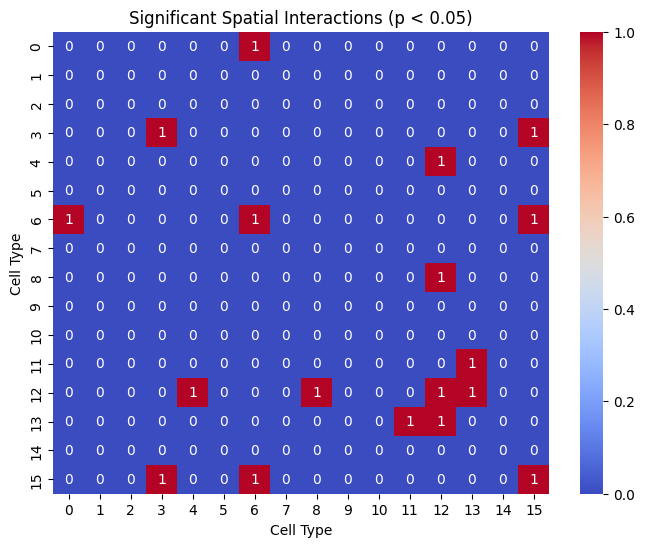

In [22]:
# binary significance matrix (1 = significant, 0 = not significant)
significant_matrix = (adata.uns["permutation_pvalues"].mean(axis=2) < 0.05).astype(int)

plt.figure(figsize=(8,6))
sns.heatmap(significant_matrix, annot=True, cmap="coolwarm")
plt.title("Significant Spatial Interactions (p < 0.05)")
plt.xlabel("Cell Type")
plt.ylabel("Cell Type")
plt.show()



In [ ]:
def permutation_co_occurrence(
    adata,
    cluster_key: str,
    n_permutations: int = 1000,
    spatial_key: str = "spatial",
    seed: int = 42
):
    """
    Perform a permutation test on spatial co-occurrence to test 
    whether observed cell-type co-localization is greater than expected by chance.

    Parameters:
    -----------
    adata : AnnData
        Annotated data matrix with spatial information.
    cluster_key : str
        Column in `adata.obs` containing categorical cluster labels (e.g., cell types).
    n_permutations : int, optional
        Number of permutations to perform, default is 1000.
    spatial_key : str, optional
        Key in `adata.obsm` storing spatial coordinates (default: "spatial").
    seed : int, optional
        Random seed for reproducibility (default: 42).

    Returns:
    --------
    adata : AnnData
        The input AnnData object with a new entry `adata.uns["permutation_pvalues"]`
        containing the p-values for cell-type co-occurrence.
    """
    np.random.seed(seed)

    # Ensure spatial coordinates are stored correctly
    if spatial_key not in adata.obsm.keys():
        raise ValueError(f"Spatial key '{spatial_key}' not found in `adata.obsm`. Run `sq.gr.spatial_neighbors()` first.")

    # Ensure cluster key exists in obs
    if cluster_key not in adata.obs.columns:
        raise ValueError(f"Cluster key '{cluster_key}' not found in `adata.obs`.")

    # Ensure cluster key is categorical
    if not pd.api.types.is_categorical_dtype(adata.obs[cluster_key]):
        adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")

    # Compute observed co-occurrence
    sq.gr.co_occurrence(adata, cluster_key=cluster_key)
    observed_matrix = adata.uns[f"{cluster_key}_co_occurrence"]["occ"].copy()

    # Perform permutations
    random_matrices = []
    for _ in range(n_permutations):
        # Shuffle cell-type labels
        shuffled_labels = np.random.permutation(adata.obs[cluster_key])
        adata.obs["shuffled_" + cluster_key] = pd.Categorical(shuffled_labels, categories=adata.obs[cluster_key].cat.categories)

        # Compute co-occurrence on shuffled data
        sq.gr.co_occurrence(adata, cluster_key="shuffled_" + cluster_key)
        permuted_matrix = adata.uns[f"shuffled_{cluster_key}_co_occurrence"]["occ"].copy()
        random_matrices.append(permuted_matrix)

    # Convert list of matrices to NumPy array
    random_matrices = np.array(random_matrices)

    # Compute p-values (how often does the permuted result exceed the observed?)
    p_values = (random_matrices >= observed_matrix).sum(axis=0) / n_permutations

    # Store results
    adata.uns["permutation_pvalues"] = p_values
    return adata


In [21]:
# Ensure spatial neighbors are computed first
sq.gr.spatial_neighbors(adata)

# Run the permutation test for cell-type spatial co-occurrence
adata = permutation_co_occurrence(adata, cluster_key="Cell_class", n_permutations=10)

# Check the results
print(adata.uns["permutation_pvalues"])


  0%|          | 0/1 [00:00<?, ?/s]

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


  0%|          | 0/1 [00:00<?, ?/s]

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


  0%|          | 0/1 [00:00<?, ?/s]

...

  0%|          | 0/1 [00:00<?, ?/s]

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


  0%|          | 0/1 [00:00<?, ?/s]

/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/melissafasol/micromamba/envs/spatial_pert/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


[[[0.  0.  0.  ... 1.  1.  1. ]
  [0.  0.  0.  ... 1.  1.  1. ]
  [0.  0.  0.  ... 1.  1.  1. ]
  ...
  [0.5 0.3 0.6 ... 0.9 1.  1. ]
  [0.  0.2 0.1 ... 1.  1.  1. ]
  [0.  0.  0.  ... 0.7 0.9 0.7]]

 [[0.  0.  0.  ... 1.  1.  1. ]
  [0.  0.  0.  ... 1.  1.  1. ]
  [0.  0.  0.  ... 1.  1.  1. ]
  ...
  [0.4 0.2 0.4 ... 0.2 0.1 0.4]
  [0.  0.  0.  ... 1.  1.  1. ]
  [0.1 0.  0.  ... 1.  1.  1. ]]

 [[0.  0.  0.  ... 1.  1.  1. ]
  [0.  0.  0.  ... 1.  1.  1. ]
  [0.3 0.  0.  ... 1.  1.  1. ]
  ...
  [1.  0.7 0.5 ... 0.3 0.7 0.4]
  [0.2 0.3 0.7 ... 1.  1.  1. ]
  [1.  1.  1.  ... 0.6 0.7 0.7]]

 ...

 [[0.5 0.3 0.6 ... 0.9 1.  1. ]
  [0.4 0.2 0.4 ... 0.2 0.1 0.4]
  [1.  0.7 0.5 ... 0.3 0.7 0.4]
  ...
  [1.  1.  1.  ... 0.4 0.4 0.4]
  [1.  0.  0.  ... 0.  0.  0.3]
  [1.  1.  1.  ... 1.  1.  1. ]]

 [[0.  0.2 0.1 ... 1.  1.  1. ]
  [0.  0.  0.  ... 1.  1.  1. ]
  [0.2 0.3 0.7 ... 1.  1.  1. ]
  ...
  [1.  0.  0.  ... 0.  0.  0.3]
  [0.  0.  0.  ... 1.  1.  1. ]
  [1.  1.  0.  ... 1.  0.9 0